# Preprocesamiento

In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import datetime
from datetime import date
from scipy import ndimage
import openeo

In [3]:
connection = openeo.connect("https://openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


## Coordenadas y fechas de los lagos

In [4]:
lago_atitlan = {
    "west": -91.326256,
    "east": -91.07151,
    "south": 14.5948,
    "north": 14.750979
}
lago_amatitlan = {
    "west": -90.638065,
    "east": -90.512924,
    "south": 14.412347,
    "north": 14.493799
}

fechas_atitlan = [
    "2025-01-18", "2025-04-13", "2025-05-13", "2025-07-17",
    "2025-11-21", "2025-12-29", "2026-02-12", "2026-03-24",
    "2026-04-13", "2026-04-28", "2026-07-22"
]

fechas_amatitlan = [
    "2025-01-28", "2025-04-15", "2025-04-28", "2025-11-24",
    "2026-01-08", "2026-02-02", "2026-02-07", "2026-03-29",
    "2026-04-13", "2026-04-28", "2026-06-19"
]

lagos = {
    "atitlan": {"bbox": lago_atitlan, "fechas": fechas_atitlan},
    "amatitlan": {"bbox": lago_amatitlan, "fechas": fechas_amatitlan},
}

## Función para quitar máscara de agua

Esta función quita el ruido de los grupos de pixeles de agua aislados de los lagos principales

In [5]:
from scipy import ndimage

def limpiar_mascara(mascara_agua, min_pixeles=30):
    """Quita grupos de pixeles 'agua' aislados (ruido) y deja solo el cuerpo de agua principal."""
    etiquetas, n = ndimage.label(mascara_agua)
    if n == 0:
        return mascara_agua
    tamanos = ndimage.sum(mascara_agua, etiquetas, range(1, n + 1))
    componente_mas_grande = np.argmax(tamanos) + 1
    return etiquetas == componente_mas_grande

## Datos de entrada

In [6]:
carpeta_datos = "data"  

faltantes = [
    f"{lago}_{fecha}"
    for lago, info in lagos.items()
    for fecha in info["fechas"]
    if not os.path.exists(f"{carpeta_datos}/{lago}_{fecha}.tif")
]
if faltantes:
    print("Faltan estos .tif (vuelve a correr la descarga del Ejercicio 2 si es necesario):", faltantes)
else:
    print("Todos los .tif de la Parte I están disponibles en 'data/'. Listo para continuar.")

Todos los .tif de la Parte I están disponibles en 'data/'. Listo para continuar.


## Función Raster

Por cada pixel válido guardamos su ubicación (x, y en las coordenadas del raster) y los valores de las 4 bandas. La limpieza pasa por 3 filtros antes de armar la tabla:

1. Nodata/inválidos: NaN o reflectancias negativas.
2. Fuera del lago: usamos NDWI = (B03-B08)/(B03+B08) > 0 como máscara de agua, y limpiar_mascara() para quedarnos solo con el cuerpo de agua principal.
3. Nubes/saturación: usamos una heurística, el brillo promedio de las 4 bandas por pixel. Descartamos el 0.5% de píxeles más brillantes dentro del agua, ya que un brillo anormalmente alto en agua típicamente indica nube, neblina o reflejo especular, no agua limpia.

In [7]:
def categorizar_cianobacteria(chl):
    """Umbrales OMS (WHO, 2003) para clorofila-a en aguas recreativas con dominancia de cianobacterias."""
    return np.select(
        [chl < 10, (chl >= 10) & (chl <= 50), chl > 50],
        ["Bajo", "Moderado", "Alto"],
        default="Bajo"
    )

def raster_a_dataframe(tif_path, lago, fecha, n_muestras=None, semilla=42, verbose=True, offset=1000):
    with rasterio.open(tif_path) as src:
        b03, b04, b05, b08 = src.read().astype(float)  # orden de descarga del Ejercicio 2
        nodata = src.nodata
        transform = src.transform

    n_total = b03.size

    # 1.3a: nodata / valores inválidos ---
    valido = np.ones(b03.shape, dtype=bool)
    for banda in (b03, b04, b05, b08):
        valido &= ~np.isnan(banda)
        if nodata is not None:
            valido &= (banda != nodata)
        valido &= (banda >= 0)

    # 1.3b: fuera del lago (máscara de agua vía NDWI) ---
    epsilon = 1e-6
    ndwi_bruto = (b03 - b08) / (b03 + b08 + epsilon)
    mascara_agua_bruta = (ndwi_bruto > 0) & valido
    mascara_agua = limpiar_mascara(mascara_agua_bruta)

    # 1.3c: nubes / saturación (brillo extremo, usando B03/B04/B08 ya que no hay B02) ---
    brillo = (b03 + b04 + b08) / 3
    if mascara_agua.any():
        umbral_brillo = np.nanpercentile(brillo[mascara_agua], 99.5)
    else:
        umbral_brillo = np.inf
    no_saturado = brillo < umbral_brillo

    mascara_final = mascara_agua & no_saturado
    n_final = mascara_final.sum()

    if verbose:
        print(f"{lago} {fecha}: {n_total:>8,} pixeles totales -> "
              f"{mascara_agua_bruta.sum():>7,} en agua (bruto) -> "
              f"{mascara_agua.sum():>7,} tras limpiar ruido -> "
              f"{n_final:>7,} tras filtrar brillo/nubes")

    # 1.2: variables derivadas (mismo offset que calcular_indices de la Parte I) ---
    b03o, b04o, b05o, b08o = b03 + offset, b04 + offset, b05 + offset, b08 + offset

    def safe_div(num, den):
        return np.where(den != 0, num / (den + epsilon), np.nan)

    ndvi_full = np.clip(safe_div(b08o - b04o, b08o + b04o), -1, 1)
    ndwi_full = np.clip(safe_div(b03o - b08o, b03o + b08o), -1, 1)
    ndci_full = np.clip(safe_div(b05o - b04o, b05o + b04o), -1, 1)
    chl_full = np.clip(826.57 * ndci_full**3 - 176.43 * ndci_full**2 + 19 * ndci_full + 4.071, 0, None)

    filas, cols = np.where(mascara_final)
    xs, ys = rasterio.transform.xy(transform, filas, cols)
    chl_vals = chl_full[filas, cols]

    df = pd.DataFrame({
        "lago": lago,
        "fecha": fecha,
        "x": xs,
        "y": ys,
        "b03": b03[filas, cols],
        "b04": b04[filas, cols],
        "b05": b05[filas, cols],
        "b08": b08[filas, cols],
        "ndvi": ndvi_full[filas, cols],
        "ndwi": ndwi_full[filas, cols],
        "ndci": ndci_full[filas, cols],
        "chl": chl_vals,
        "categoria_cianobacteria": categorizar_cianobacteria(chl_vals),
    })

    if n_muestras is not None and len(df) > 0:
        n = min(n_muestras, len(df))
        df = df.sample(n=n, random_state=semilla).reset_index(drop=True)

    return df

## Aplicar a todos los lagos y fechas con sampling balanceado

Con 11 fechas por cada lago, cada raster tiene cientos de miles de píxeles. En vez de muestrear por porcentaje, usamos un número fijo de píxeles por fecha para que Atitlán y Amatitlán aporten cantidades comparables al dataset final (si usáramos el mismo porcentaje para ambos, Atitlán dominaría el dataset casi 17 a 1 sobre Amatitlán).

In [8]:
frames = []

for lago, info in lagos.items():
    for fecha in info["fechas"]:
        tif_path = f"data/{lago}_{fecha}.tif"
        if not os.path.exists(tif_path):
            continue
        df_fecha = raster_a_dataframe(tif_path, lago, fecha, n_muestras=20000)
        frames.append(df_fecha)

df_ml = pd.concat(frames, ignore_index=True)
df_ml["fecha"] = pd.to_datetime(df_ml["fecha"])
print(f"\nTotal filas en el dataset final: {len(df_ml):,}")
print(df_ml["lago"].value_counts())
df_ml.head()

atitlan 2025-01-18: 4,831,009 pixeles totales -> 303,380 en agua (bruto) ->  89,638 tras limpiar ruido ->  89,187 tras filtrar brillo/nubes
atitlan 2025-04-13: 4,831,009 pixeles totales -> 1,227,193 en agua (bruto) -> 1,226,314 tras limpiar ruido -> 1,220,154 tras filtrar brillo/nubes
atitlan 2025-05-13: 4,831,009 pixeles totales -> 1,397,610 en agua (bruto) -> 1,226,056 tras limpiar ruido -> 1,219,900 tras filtrar brillo/nubes
atitlan 2025-07-17: 4,831,009 pixeles totales -> 1,202,490 en agua (bruto) -> 1,199,084 tras limpiar ruido -> 1,193,063 tras filtrar brillo/nubes
atitlan 2025-11-21: 4,831,009 pixeles totales -> 1,058,914 en agua (bruto) -> 981,688 tras limpiar ruido -> 976,772 tras filtrar brillo/nubes
atitlan 2025-12-29: 4,831,009 pixeles totales -> 1,305,708 en agua (bruto) -> 1,121,757 tras limpiar ruido -> 1,116,136 tras filtrar brillo/nubes
atitlan 2026-02-12: 4,831,009 pixeles totales -> 964,722 en agua (bruto) -> 936,931 tras limpiar ruido -> 932,246 tras filtrar brillo/

,lago,fecha,x,y,b03,b04,b05,b08,ndvi,ndwi,ndci,chl,categoria_cianobacteria
0,atitlan,2025-01-18,688545.0,1626205.0,111.0,15.0,1.0,20.0,0.002457,0.042703,-0.006944,3.930270,Bajo
1,atitlan,2025-01-18,688035.0,1625545.0,128.0,14.0,9.0,20.0,0.002950,0.050279,-0.002472,4.022950,Bajo
2,atitlan,2025-01-18,689045.0,1624965.0,109.0,19.0,9.0,20.0,0.000490,0.041804,-0.004931,3.972923,Bajo
3,atitlan,2025-01-18,687385.0,1625825.0,113.0,13.0,12.0,22.0,0.004423,0.042623,-0.000494,4.061574,Bajo
4,atitlan,2025-01-18,688165.0,1626055.0,109.0,7.0,11.0,20.0,0.006413,0.041804,0.001982,4.107974,Bajo


## Resumen del dataset

In [9]:
print(f"Total de observaciones: {len(df_ml):,}\n")

print("Observaciones por lago:")
print(df_ml["lago"].value_counts(), "\n")

print("Observaciones por lago y fecha:")
display(df_ml.groupby(["lago", "fecha"]).size().rename("n_observaciones").reset_index())

print("\nTipos de variable:")
print(df_ml.dtypes, "\n")

print("Porcentaje de valores faltantes por columna:")
print((df_ml.isna().mean() * 100).round(2).astype(str) + " %")

Total de observaciones: 440,000

Observaciones por lago:
lago
atitlan      220000
amatitlan    220000
Name: count, dtype: int64 

Observaciones por lago y fecha:


,lago,fecha,n_observaciones
0,amatitlan,2025-01-28,20000
1,amatitlan,2025-04-15,20000
2,amatitlan,2025-04-28,20000
3,amatitlan,2025-11-24,20000
4,amatitlan,2026-01-08,20000
5,amatitlan,2026-02-02,20000
6,amatitlan,2026-02-07,20000
7,amatitlan,2026-03-29,20000
8,amatitlan,2026-04-13,20000
9,amatitlan,2026-04-28,20000



Tipos de variable:
lago                               object
fecha                      datetime64[ns]
x                                 float64
y                                 float64
b03                               float64
b04                               float64
b05                               float64
b08                               float64
ndvi                              float64
ndwi                              float64
ndci                              float64
chl                               float64
categoria_cianobacteria            object
dtype: object 

Porcentaje de valores faltantes por columna:
lago                       0.0 %
fecha                      0.0 %
x                          0.0 %
y                          0.0 %
b03                        0.0 %
b04                        0.0 %
b05                        0.0 %
b08                        0.0 %
ndvi                       0.0 %
ndwi                       0.0 %
ndci                       0.0 %
chl       

## Análisis exploratorio

In [10]:
variables_numericas = ["b03", "b04", "b05", "b08", "ndvi", "ndwi", "ndci", "chl"]
df_ml[variables_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
b03,440000.0,379.153055,832.859169,56.000000,153.000000,214.000000,506.000000,19551.000000
b04,440000.0,233.236180,786.216970,0.000000,77.000000,123.000000,261.000000,18623.000000
b05,440000.0,321.931741,856.278815,0.000000,79.000000,169.000000,447.000000,18098.000000
b08,440000.0,205.334566,773.731996,0.000000,44.000000,102.000000,231.000000,17159.000000
ndvi,440000.0,-0.011149,0.020177,-0.276596,-0.019548,-0.006967,0.000000,0.166293
ndwi,440000.0,0.064571,0.041241,0.000065,0.040528,0.051271,0.072179,0.268167
ndci,440000.0,0.029173,0.045131,-0.128350,-0.000974,0.009649,0.038111,0.315919
chl,440000.0,4.423121,0.574309,0.000000,4.052331,4.238644,4.584606,18.526904


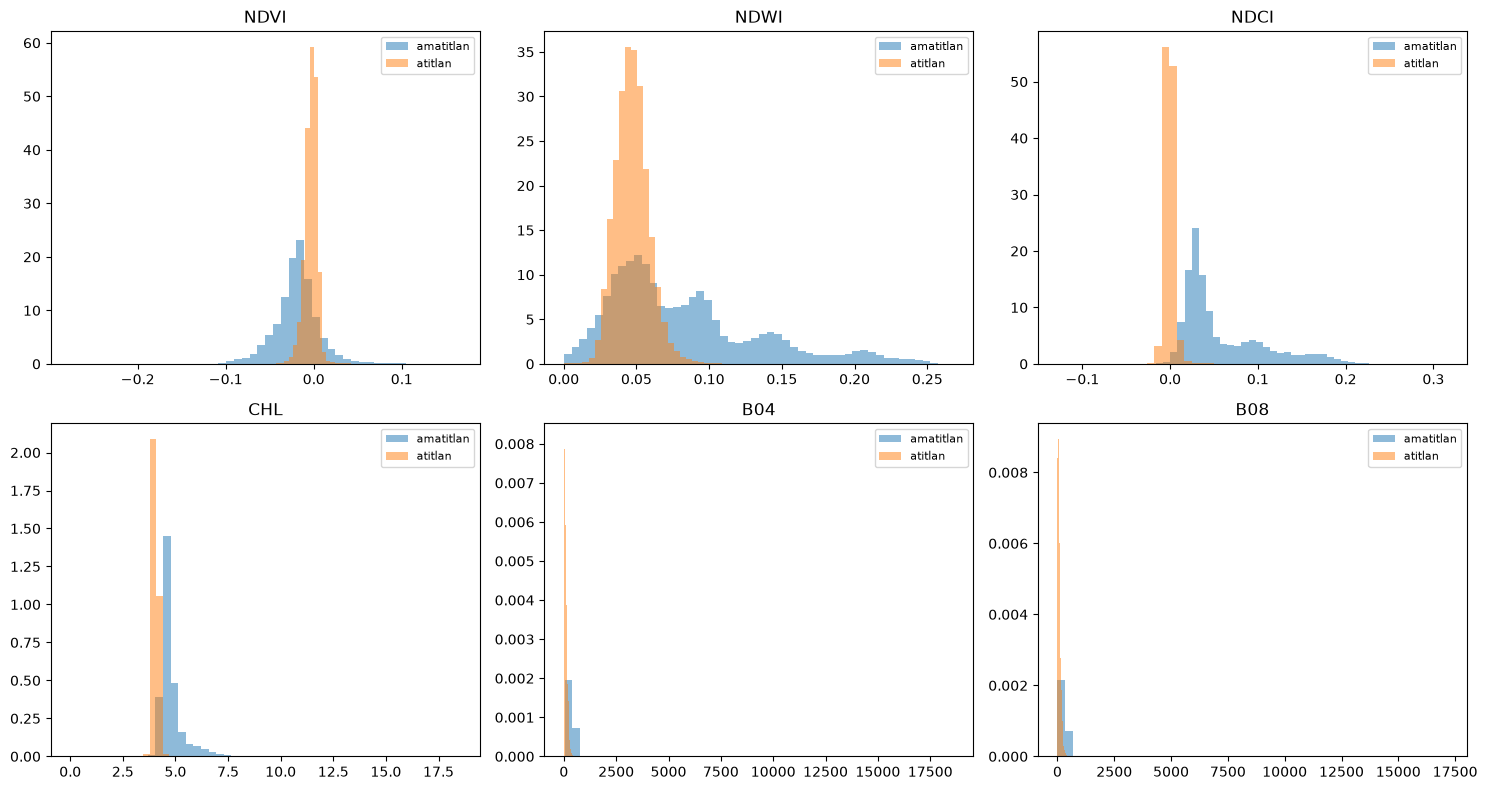

In [11]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.ravel()

for ax, var in zip(axs, ["ndvi", "ndwi", "ndci", "chl", "b04", "b08"]):
    for lago, grupo in df_ml.groupby("lago"):
        ax.hist(grupo[var], bins=50, alpha=0.5, label=lago, density=True)
    ax.set_title(var.upper())
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("eda_distribuciones.png", dpi=150)
plt.show()

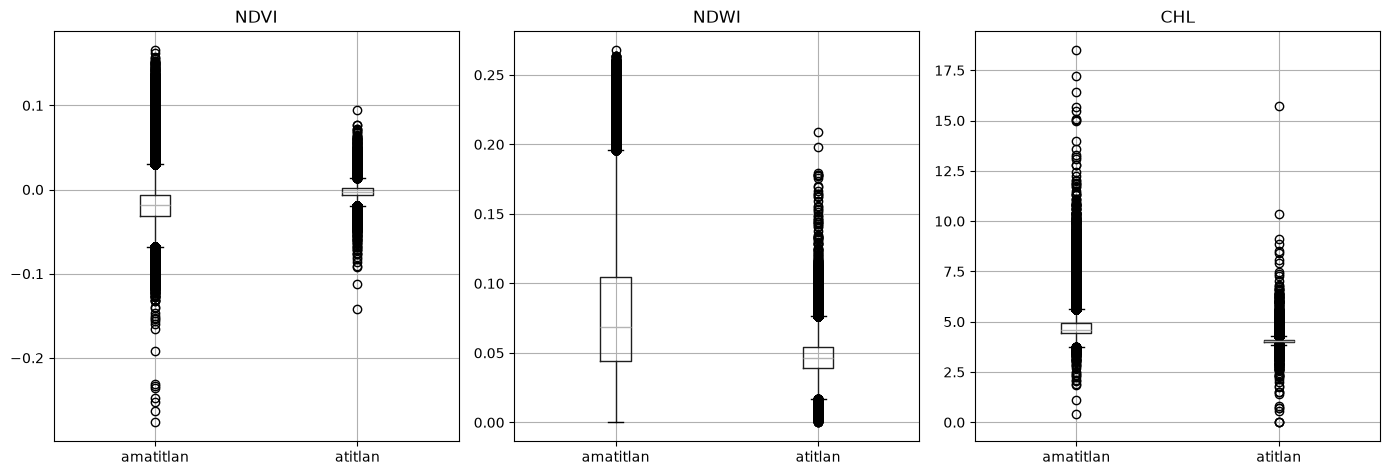

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(14, 5))

for ax, var in zip(axs, ["ndvi", "ndwi", "chl"]):
    df_ml.boxplot(column=var, by="lago", ax=ax)
    ax.set_title(var.upper())
    ax.set_xlabel("")

plt.suptitle("")
plt.tight_layout()
plt.savefig("eda_boxplots.png", dpi=150)
plt.show()

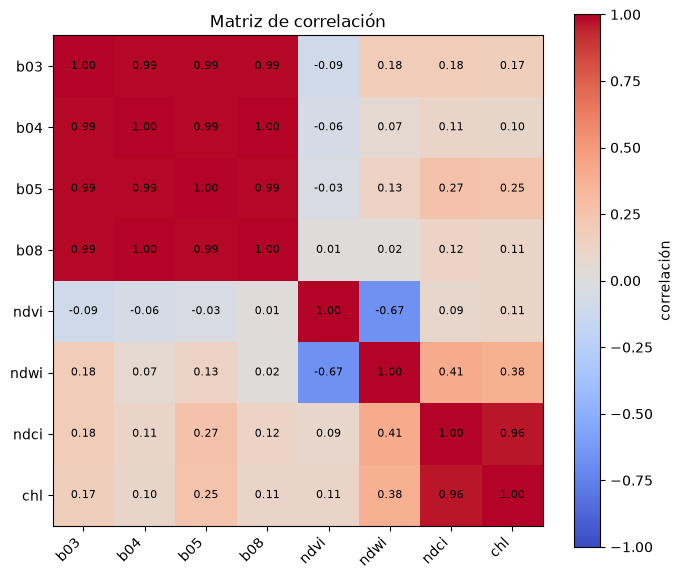

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
corr = df_ml[variables_numericas].corr()
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(variables_numericas)))
ax.set_yticks(range(len(variables_numericas)))
ax.set_xticklabels(variables_numericas, rotation=45, ha="right")
ax.set_yticklabels(variables_numericas)
for i in range(len(variables_numericas)):
    for j in range(len(variables_numericas)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, label="correlación")
plt.title("Matriz de correlación")
plt.tight_layout()
plt.savefig("eda_correlacion.png", dpi=150)
plt.show()

Distribución de categoría de cianobacteria por lago (%):


categoria_cianobacteria,Bajo,Moderado
lago,,
amatitlan,100.0,0.0
atitlan,100.0,0.0


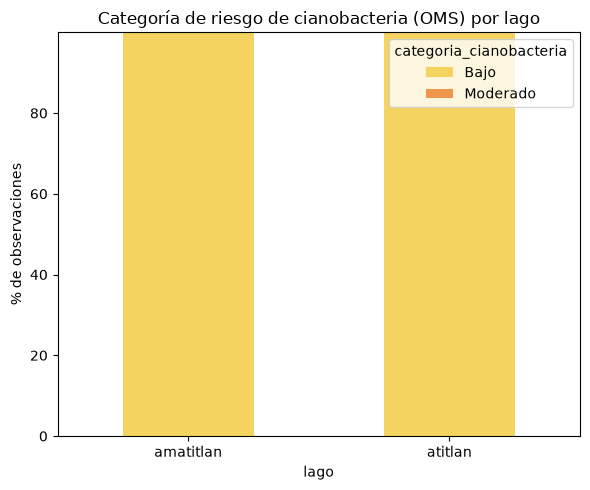

In [14]:
tabla_categoria = pd.crosstab(df_ml["lago"], df_ml["categoria_cianobacteria"], normalize="index") * 100
print("Distribución de categoría de cianobacteria por lago (%):")
display(tabla_categoria.round(1))

tabla_categoria.plot(kind="bar", stacked=True, figsize=(6, 5), color=["#f4d35e", "#ee964b", "#c1121f"])
plt.ylabel("% de observaciones")
plt.title("Categoría de riesgo de cianobacteria (OMS) por lago")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("eda_categoria_cianobacteria.png", dpi=150)
plt.show()

---
# Ejercicio 2 — Construcción de la variable respuesta

## 2.1 Construcción de la variable respuesta binaria

A partir de los resultados obtenidos (clorofila-a estimada mediante NDCI), construimos una variable respuesta binaria `alta_cianobacteria`:
- `0` = ausencia o baja presencia de cianobacteria
- `1` = alta presencia de cianobacteria

In [15]:
# Variable respuesta binaria (umbral relativo, percentil 90)
UMBRAL_ALTA_PRESENCIA = df_ml["chl"].quantile(0.90)

df_ml["alta_cianobacteria"] = (df_ml["chl"] >= UMBRAL_ALTA_PRESENCIA).astype(int)

print(f"Umbral relativo (percentil 90 de chl): {UMBRAL_ALTA_PRESENCIA:.3f} mg/m³")
print(df_ml["alta_cianobacteria"].value_counts())
print((df_ml["alta_cianobacteria"].value_counts(normalize=True) * 100).round(2))

df_ml[["chl", "categoria_cianobacteria", "alta_cianobacteria"]].sample(10, random_state=42)

Umbral relativo (percentil 90 de chl): 5.016 mg/m³
alta_cianobacteria
0    396000
1     44000
Name: count, dtype: int64
alta_cianobacteria
0    90.0
1    10.0
Name: proportion, dtype: float64


,chl,categoria_cianobacteria,alta_cianobacteria
115210,3.985204,Bajo,0
263725,4.582478,Bajo,0
374327,4.973631,Bajo,0
372551,5.215973,Bajo,1
15598,4.033023,Bajo,0
245693,4.599319,Bajo,0
367675,4.923230,Bajo,0
242691,5.017451,Bajo,1
428298,6.084703,Bajo,1
123285,4.004200,Bajo,0


## 2.3 Distribución de la variable respuesta globalmente, por lago y por fecha


--- Distribución por lago (%): ---


alta_cianobacteria,0,1
lago,,
amatitlan,80.1,19.9
atitlan,99.9,0.1



--- Distribución por fecha (%): ---


alta_cianobacteria,0,1
fecha,,
2025-01-18,100.0,0.0
2025-01-28,98.7,1.3
2025-04-13,99.9,0.1
2025-04-15,77.9,22.1
2025-04-28,99.5,0.5
2025-05-13,99.9,0.1
2025-07-17,99.8,0.2
2025-11-21,100.0,0.0
2025-11-24,99.9,0.1


/var/folders/dc/_dt3fhrs48n2b_4mmncch3440000gp/T/ipykernel_78688/3612040037.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_ml, x='alta_cianobacteria', palette='Set2')


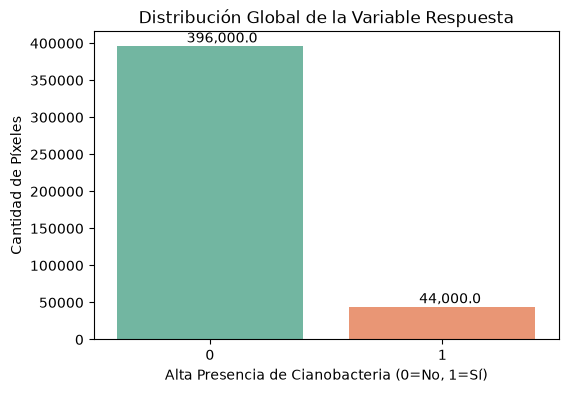

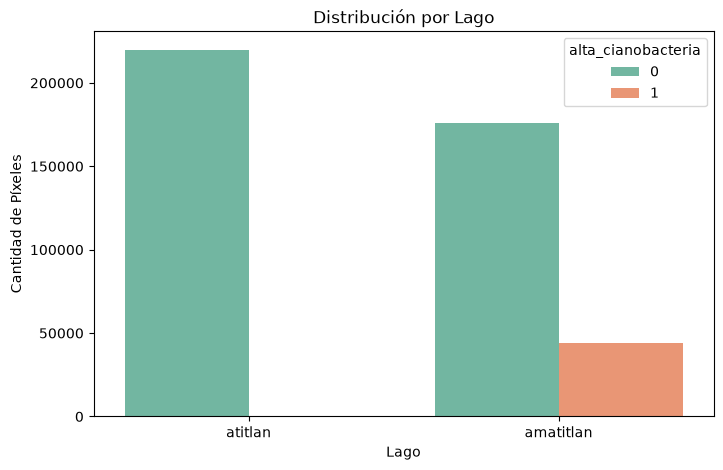

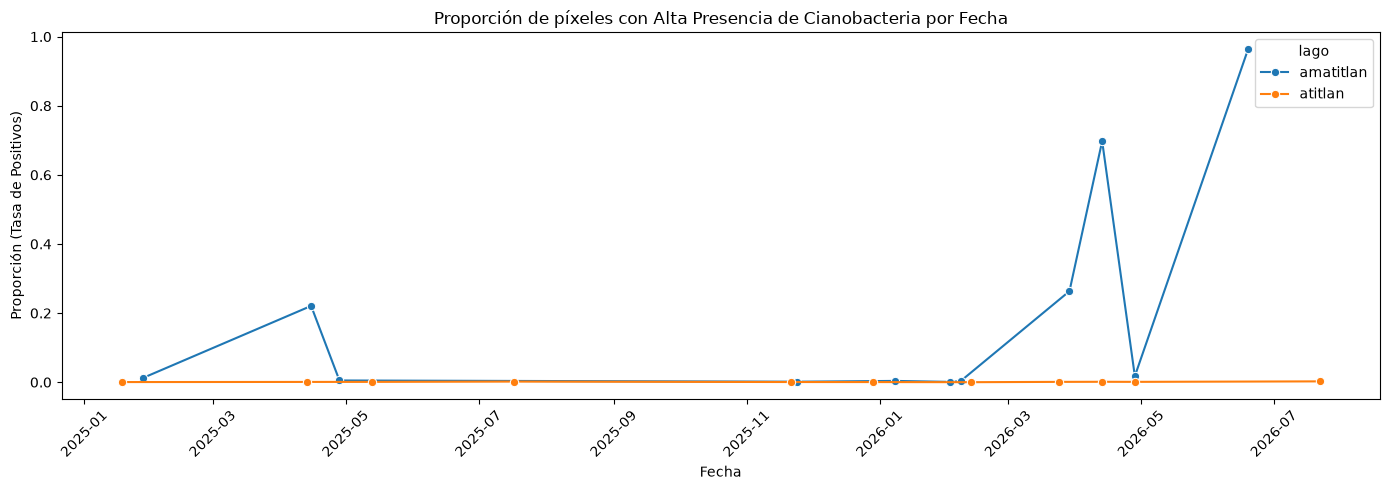

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- Distribución por lago (%): ---")
tabla_lago = pd.crosstab(df_ml["lago"], df_ml["alta_cianobacteria"], normalize="index") * 100
display(tabla_lago.round(1))

print("\n--- Distribución por fecha (%): ---")
tabla_fecha = pd.crosstab(df_ml["fecha"], df_ml["alta_cianobacteria"], normalize="index") * 100
display(tabla_fecha.round(1))

# 1. Distribución global
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_ml, x='alta_cianobacteria', palette='Set2')
plt.title('Distribución Global de la Variable Respuesta')
plt.xlabel('Alta Presencia de Cianobacteria (0=No, 1=Sí)')
plt.ylabel('Cantidad de Píxeles')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x()+0.3, p.get_height()+5000))
plt.show()

# 2. Distribución por lago
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_ml, x='lago', hue='alta_cianobacteria', palette='Set2')
plt.title('Distribución por Lago')
plt.xlabel('Lago')
plt.ylabel('Cantidad de Píxeles')
plt.show()

# 3. Distribución por fecha (proporción)
fecha_lago_dist = df_ml.groupby(['lago', 'fecha'])['alta_cianobacteria'].mean().reset_index()
plt.figure(figsize=(14, 5))
sns.lineplot(data=fecha_lago_dist, x='fecha', y='alta_cianobacteria', hue='lago', marker='o')
plt.title('Proporción de píxeles con Alta Presencia de Cianobacteria por Fecha')
plt.xlabel('Fecha')
plt.ylabel('Proporción (Tasa de Positivos)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2.4 Análisis de desbalance de clases

In [19]:
conteo = df_ml["alta_cianobacteria"].value_counts()
prop = df_ml["alta_cianobacteria"].value_counts(normalize=True)
ratio = conteo.max() / conteo.min()

print(f"Clase 0 (baja/sin presencia): {conteo.get(0,0):,} ({prop.get(0,0)*100:.1f}%)")
print(f"Clase 1 (alta presencia):     {conteo.get(1,0):,} ({prop.get(1,0)*100:.1f}%)")
print(f"Razón de desbalance: {ratio:.1f} : 1")

Clase 0 (baja/sin presencia): 396,000 (90.0%)
Clase 1 (alta presencia):     44,000 (10.0%)
Razón de desbalance: 9.0 : 1


## 2.5 Variables que no pueden utilizarse como predictoras


In [20]:
variables_prohibidas = ["chl", "ndci", "categoria_cianobacteria", "b05"]
print("Variables prohibidas para predecir:", variables_prohibidas)

Variables prohibidas para predecir: ['chl', 'ndci', 'categoria_cianobacteria', 'b05']


# 3.Selección y construcción de variables predictoras

In [23]:
# --- Ejercicio 3: construcción del conjunto de variables predictoras ---

# 3.3 Ingeniería de características: estacionalidad (codificación cíclica del día del año)
# Se evita que diciembre (12) y enero (1) queden artificialmente lejos.
df_ml["fecha"] = pd.to_datetime(df_ml["fecha"])
_doy = df_ml["fecha"].dt.dayofyear
df_ml["doy_sin"] = np.sin(2 * np.pi * _doy / 365.25)
df_ml["doy_cos"] = np.cos(2 * np.pi * _doy / 365.25)

# 3.1 Definición de los conjuntos de predictoras (respeta variables_prohibidas del 2.5)
PRED_ESPECTRALES = ["b03", "b04", "b08", "ndvi", "ndwi"]   # b05, ndci, chl EXCLUIDAS (fuga, 2.5)
PRED_TEMPORALES  = ["doy_sin", "doy_cos"]                  # estacionalidad transferible
PRED_ESPACIALES  = ["x", "y"]                              # NO en modelo base; solo Ej.6 y Ej.9

# Conjunto recomendado para los modelos (Ej. 4), transferible entre lagos:
predictoras = PRED_ESPECTRALES + PRED_TEMPORALES

# Verificación de que ninguna predictora sea una variable prohibida (control de fuga)
fuga = [v for v in predictoras if v in variables_prohibidas]
assert not fuga, f"Hay predictoras con fuga de informacion: {fuga}"

X = df_ml[predictoras].copy()
y = df_ml["alta_cianobacteria"].astype(int)

print("Predictoras del modelo base:", predictoras)
print("X:", X.shape, "| y positivos:", round(float(y.mean()), 3))
print("Sin fuga de informacion (ninguna predictora en variables_prohibidas):", not fuga)
X.head()

Predictoras del modelo base: ['b03', 'b04', 'b08', 'ndvi', 'ndwi', 'doy_sin', 'doy_cos']
X: (440000, 7) | y positivos: 0.1
Sin fuga de informacion (ninguna predictora en variables_prohibidas): True


,b03,b04,b08,ndvi,ndwi,doy_sin,doy_cos
0,111.0,15.0,20.0,0.002457,0.042703,0.304719,0.952442
1,128.0,14.0,20.0,0.002950,0.050279,0.304719,0.952442
2,109.0,19.0,20.0,0.000490,0.041804,0.304719,0.952442
3,113.0,13.0,22.0,0.004423,0.042623,0.304719,0.952442
4,109.0,7.0,20.0,0.006413,0.041804,0.304719,0.952442


# 4. Construcción de modelos de Machine Learning

## División en train y tes (70/30)

In [22]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

print(f"Train: {X_train.shape[0]:,} filas | positivos: {y_train.mean()*100:.2f}%")
print(f"Test:  {X_test.shape[0]:,} filas | positivos: {y_test.mean()*100:.2f}%")

Train: 308,000 filas | positivos: 10.00%
Test:  132,000 filas | positivos: 10.00%


## Modelos y ajuste de hiperparámetros

In [23]:
cv_estratificado = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

### Regresión lineal

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42)),
])

param_lr = {"modelo__C": [0.001, 0.01, 0.1, 1, 10, 100]}

busqueda_lr = RandomizedSearchCV(
    pipe_lr, param_lr, n_iter=6, scoring="recall",
    cv=cv_estratificado, random_state=42, n_jobs=-1
)
busqueda_lr.fit(X_train, y_train)

modelo_lr = busqueda_lr.best_estimator_
print("Mejor C:", busqueda_lr.best_params_)
print("Mejor recall (CV):", round(busqueda_lr.best_score_, 3))

/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarnin

Mejor C: {'modelo__C': 0.001}
Mejor recall (CV): 0.923


### Random Forest

In [25]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf_base = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)

param_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_leaf": [1, 5, 10],
}

busqueda_rf = RandomizedSearchCV(
    modelo_rf_base, param_rf, n_iter=8, scoring="recall",
    cv=cv_estratificado, random_state=42, n_jobs=-1
)
busqueda_rf.fit(X_train, y_train)

modelo_rf = busqueda_rf.best_estimator_
print("Mejores hiperparámetros:", busqueda_rf.best_params_)
print("Mejor recall (CV):", round(busqueda_rf.best_score_, 3))

Mejores hiperparámetros: {'n_estimators': 200, 'min_samples_leaf': 10, 'max_depth': 10}
Mejor recall (CV): 0.976


### Gradient Boosting

In [26]:
from sklearn.ensemble import GradientBoostingClassifier

# Peso por muestra inversamente proporcional a la frecuencia de su clase
peso_clase0 = 1.0
peso_clase1 = (y_train == 0).sum() / (y_train == 1).sum()
sample_weight_train = np.where(y_train == 1, peso_clase1, peso_clase0)

modelo_gb_base = GradientBoostingClassifier(random_state=42)

param_gb = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4],
}

busqueda_gb = RandomizedSearchCV(
    modelo_gb_base, param_gb, n_iter=8, scoring="recall",
    cv=cv_estratificado, random_state=42, n_jobs=-1
)
busqueda_gb.fit(X_train, y_train, sample_weight=sample_weight_train)

modelo_gb = busqueda_gb.best_estimator_
print("Mejores hiperparámetros:", busqueda_gb.best_params_)
print("Mejor recall (CV):", round(busqueda_gb.best_score_, 3))

Mejores hiperparámetros: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}
Mejor recall (CV): 0.98


# 5. Evaluación de los modelos

## Métricas y matriz de confusión para cada modelo

/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

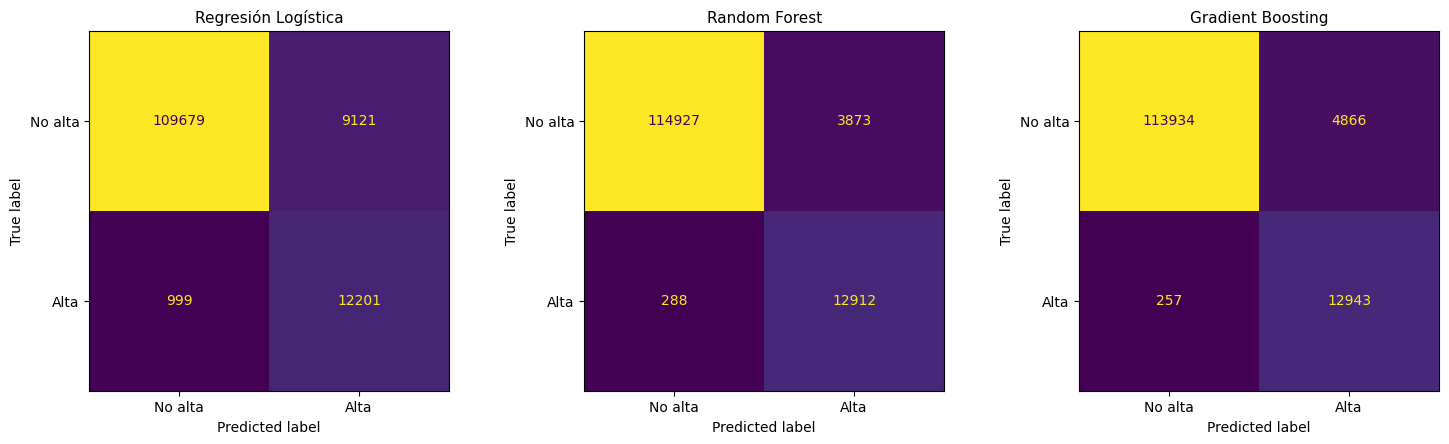

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Modelo,,,,,
Regresión Logística,0.9233,0.5722,0.9243,0.7069,0.9667
Random Forest,0.9685,0.7693,0.9782,0.8612,0.9962
Gradient Boosting,0.9612,0.7268,0.9805,0.8348,0.9946


In [27]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

modelos = {
    "Regresión Logística": modelo_lr,
    "Random Forest": modelo_rf,
    "Gradient Boosting": modelo_gb,
}

resultados = []

fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (nombre, modelo) in zip(axs, modelos.items()):
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    metricas = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    }
    resultados.append(metricas)

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["No alta", "Alta"]).plot(ax=ax, colorbar=False)
    ax.set_title(nombre, fontsize=11)

plt.tight_layout()
plt.savefig("matrices_confusion.png", dpi=150)
plt.show()

tabla_resultados = pd.DataFrame(resultados).set_index("Modelo").round(4)
tabla_resultados

## Comparación de desempeño

/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


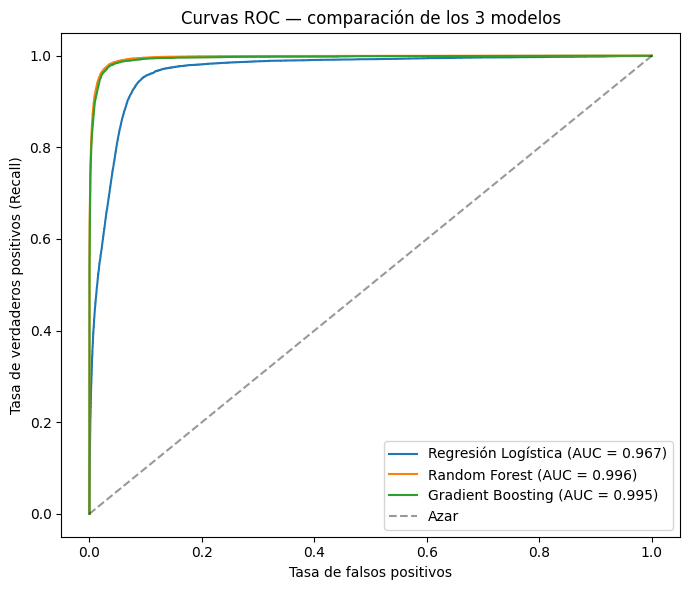

Tabla comparativa de métricas:


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Modelo,,,,,
Random Forest,0.9685,0.7693,0.9782,0.8612,0.9962
Gradient Boosting,0.9612,0.7268,0.9805,0.8348,0.9946
Regresión Logística,0.9233,0.5722,0.9243,0.7069,0.9667



Mejor modelo por ROC-AUC: Random Forest
Mejor modelo por Recall: Gradient Boosting


In [28]:
plt.figure(figsize=(7, 6))
for nombre, modelo in modelos.items():
    y_proba = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Azar")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos (Recall)")
plt.title("Curvas ROC — comparación de los 3 modelos")
plt.legend()
plt.tight_layout()
plt.savefig("curvas_roc.png", dpi=150)
plt.show()

print("Tabla comparativa de métricas:")
display(tabla_resultados.sort_values("ROC-AUC", ascending=False))

mejor_por_auc = tabla_resultados["ROC-AUC"].idxmax()
mejor_por_recall = tabla_resultados["Recall"].idxmax()
print(f"\nMejor modelo por ROC-AUC: {mejor_por_auc}")
print(f"Mejor modelo por Recall: {mejor_por_recall}")

# 6. Validación espacial

### 6.1. Reproyección y construcción de la cuadrícula de 1 km × 1 km

In [29]:
# 6.1: los rasters de Sentinel-2 ya vienen en EPSG:32615 (UTM 15N, metros), por lo que las
# coordenadas x, y de df_ml YA están en el sistema pedido: se verifica y no requiere reproyección.
import rasterio
with rasterio.open("data/amatitlan_2026-06-19.tif") as _src:
    print("CRS de los rasters:", _src.crs, "| unidades:", _src.crs.linear_units)

TAM_BLOQUE = 1000  # metros (1 km)

# Cada observación se asigna a una celda (bloque) de 1 km; el prefijo con el lago evita que
# celdas de lagos distintos se mezclen en un mismo bloque.
bx = (df_ml["x"] // TAM_BLOQUE).astype(int)
by = (df_ml["y"] // TAM_BLOQUE).astype(int)
df_ml["bloque"] = df_ml["lago"] + "_" + bx.astype(str) + "_" + by.astype(str)

print("\nBloques de 1 km por lago y observaciones por bloque:")
for lago, g in df_ml.groupby("lago"):
    tam = g.groupby("bloque").size()
    print(f"  {lago:10s}: {g['bloque'].nunique():3d} bloques | obs/bloque  min={tam.min()}  "
          f"mediana={tam.median():.0f}  max={tam.max()}")
print("\nUn tamaño de 1 km deja decenas de bloques por lago (>> 5 folds), suficiente para la CV espacial.")

CRS de los rasters: EPSG:32615 | unidades: metre

Bloques de 1 km por lago y observaciones por bloque:
  amatitlan :  38 bloques | obs/bloque  min=2  mediana=3992  max=24276
  atitlan   : 166 bloques | obs/bloque  min=2  mediana=1662  max=4025

Un tamaño de 1 km deja decenas de bloques por lago (>> 5 folds), suficiente para la CV espacial.


### 6.2. Asignación de observaciones a bloques y mapa de bloques

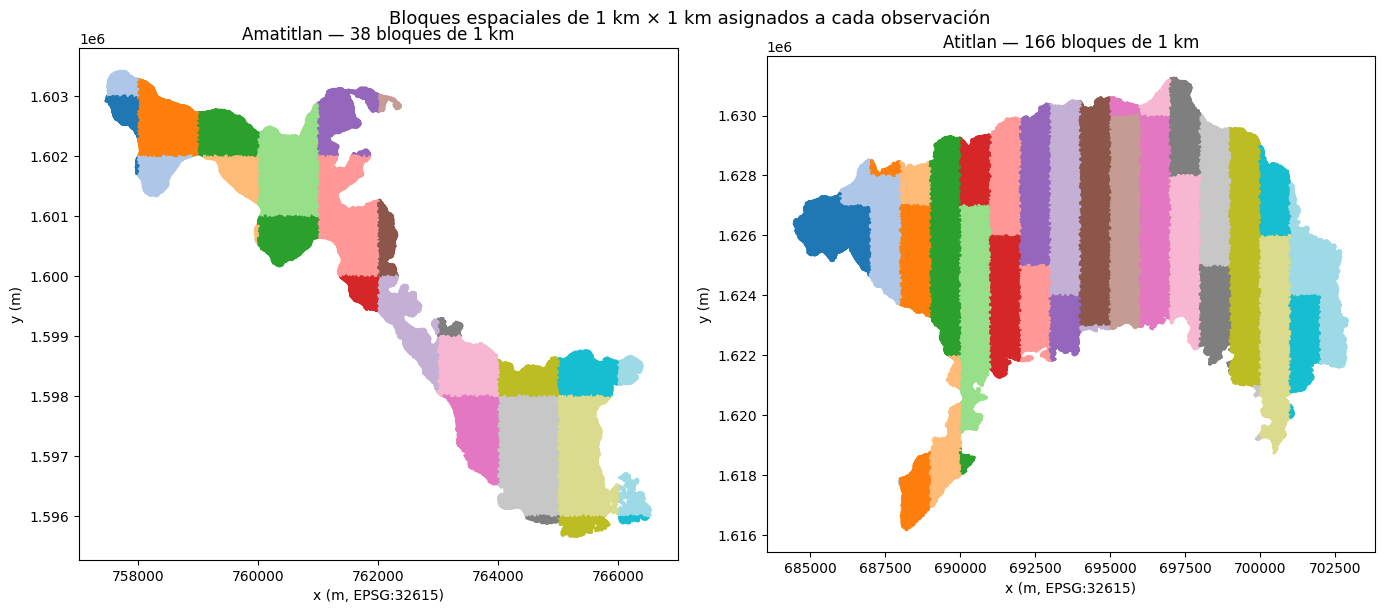

In [30]:
# 6.2: visualización de los bloques espaciales (cada color = un bloque de 1 km)
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
for ax, (lago, g) in zip(axs, df_ml.groupby("lago")):
    codigos = g["bloque"].astype("category").cat.codes
    sc = ax.scatter(g["x"], g["y"], c=codigos, cmap="tab20", s=2)
    ax.set_title(f"{lago.capitalize()} — {g['bloque'].nunique()} bloques de 1 km")
    ax.set_xlabel("x (m, EPSG:32615)"); ax.set_ylabel("y (m)")
    ax.set_aspect("equal")
fig.suptitle("Bloques espaciales de 1 km × 1 km asignados a cada observación", fontsize=13)
plt.tight_layout(); plt.savefig("bloques_espaciales.png", dpi=150); plt.show()

### 6.3–6.4. Validación espacial con GroupKFold

In [31]:
# 6.3-6.4: validación espacial (GroupKFold, el mismo bloque no se parte entre train y test)
from sklearn.model_selection import GroupKFold
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

grupos = df_ml.loc[X.index, "bloque"].values   # bloque espacial de cada observación de X
gkf = GroupKFold(n_splits=5)

def ajustar_modelo(nombre, modelo, Xtr, ytr):
    """Clona y ajusta el modelo; Gradient Boosting usa sample_weight como en el Ej. 4."""
    m = clone(modelo)
    if nombre == "Gradient Boosting":
        w = np.where(ytr == 1, (ytr == 0).sum() / max((ytr == 1).sum(), 1), 1.0)
        m.fit(Xtr, ytr, sample_weight=w)
    else:
        m.fit(Xtr, ytr)
    return m

filas_esp = []
for nombre, modelo in modelos.items():
    folds = []
    for tr, te in gkf.split(X, y, grupos):
        m = ajustar_modelo(nombre, modelo, X.iloc[tr], y.iloc[tr])
        p = m.predict(X.iloc[te]); pr = m.predict_proba(X.iloc[te])[:, 1]
        folds.append([accuracy_score(y.iloc[te], p),
                      precision_score(y.iloc[te], p, zero_division=0),
                      recall_score(y.iloc[te], p),
                      f1_score(y.iloc[te], p),
                      roc_auc_score(y.iloc[te], pr)])
    m_media = np.mean(folds, axis=0)
    filas_esp.append({"Modelo": nombre, "Accuracy": m_media[0], "Precision": m_media[1],
                      "Recall": m_media[2], "F1-score": m_media[3], "ROC-AUC": m_media[4]})

tabla_espacial = pd.DataFrame(filas_esp).set_index("Modelo").round(4)
print("Validación ESPACIAL (GroupKFold 5 folds, bloques de 1 km):")
tabla_espacial

/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/User

Validación ESPACIAL (GroupKFold 5 folds, bloques de 1 km):


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Modelo,,,,,
Regresión Logística,0.9208,0.5702,0.9172,0.6958,0.9650
Random Forest,0.9671,0.7580,0.9733,0.8512,0.9956
Gradient Boosting,0.9595,0.7140,0.9782,0.8240,0.9941


### 6.5–6.6. Comparación validación aleatoria vs. espacial

In [32]:
# 6.5: comparación lado a lado (partición aleatoria del Ej. 5 vs. validación espacial)
metr = ["Recall", "F1-score", "ROC-AUC"]
comparacion = tabla_resultados[metr].join(
    tabla_espacial[metr], lsuffix=" (aleatoria)", rsuffix=" (espacial)"
)
print("Comparación de métricas — aleatoria vs. espacial:")
display(comparacion.round(4))

# diferencia (espacial - aleatoria) para ver la magnitud de la caída
dif = (tabla_espacial[metr] - tabla_resultados[metr]).round(4)
dif.columns = [c + " (Δ esp-aleat)" for c in metr]
print("\nDiferencia espacial - aleatoria (negativo = baja al validar espacialmente):")
display(dif)

Comparación de métricas — aleatoria vs. espacial:


,Recall (aleatoria),F1-score (aleatoria),ROC-AUC (aleatoria),Recall (espacial),F1-score (espacial),ROC-AUC (espacial)
Modelo,,,,,,
Regresión Logística,0.9243,0.7069,0.9667,0.9172,0.6958,0.9650
Random Forest,0.9782,0.8612,0.9962,0.9733,0.8512,0.9956
Gradient Boosting,0.9805,0.8348,0.9946,0.9782,0.8240,0.9941



Diferencia espacial - aleatoria (negativo = baja al validar espacialmente):


,Recall (Δ esp-aleat),F1-score (Δ esp-aleat),ROC-AUC (Δ esp-aleat)
Modelo,,,
Regresión Logística,-0.0071,-0.0111,-0.0017
Random Forest,-0.0049,-0.0100,-0.0006
Gradient Boosting,-0.0023,-0.0108,-0.0005


# 7. Generalización entre lagos

In [33]:
# 7.1-7.3: Experimento A (train Atitlán -> test Amatitlán) y B (train Amatitlán -> test Atitlán)
experimentos = [
    ("A: Atitlán → Amatitlán", "atitlan", "amatitlan"),
    ("B: Amatitlán → Atitlán", "amatitlan", "atitlan"),
]
lago_de_X = df_ml.loc[X.index, "lago"]

filas_cross = []
for etiqueta, tr_lago, te_lago in experimentos:
    m = (lago_de_X == tr_lago).values
    Xtr, ytr = X[m], y[m]
    Xte, yte = X[~m], y[~m]
    for nombre, modelo in modelos.items():
        mod = ajustar_modelo(nombre, modelo, Xtr, ytr)
        p = mod.predict(Xte); pr = mod.predict_proba(Xte)[:, 1]
        filas_cross.append({
            "Experimento": etiqueta, "Modelo": nombre,
            "% pos train": round(ytr.mean() * 100, 2), "% pos test": round(yte.mean() * 100, 2),
            "Recall": recall_score(yte, p, zero_division=0),
            "F1-score": f1_score(yte, p, zero_division=0),
            "ROC-AUC": roc_auc_score(yte, pr),
        })

tabla_cross = pd.DataFrame(filas_cross).round(4)
print("Generalización entre lagos (entrenar en un lago, probar en el otro):")
tabla_cross

/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/User

Generalización entre lagos (entrenar en un lago, probar en el otro):


,Experimento,Modelo,% pos train,% pos test,Recall,F1-score,ROC-AUC
0,A: Atitlán → Amatitlán,Regresión Logística,0.09,19.91,0.9745,0.4999,0.8583
1,A: Atitlán → Amatitlán,Random Forest,0.09,19.91,0.4275,0.5800,0.9155
2,A: Atitlán → Amatitlán,Gradient Boosting,0.09,19.91,0.9985,0.4452,0.8116
3,B: Amatitlán → Atitlán,Regresión Logística,19.91,0.09,0.8636,0.0031,0.8057
4,B: Amatitlán → Atitlán,Random Forest,19.91,0.09,0.3838,0.0301,0.8754
5,B: Amatitlán → Atitlán,Gradient Boosting,19.91,0.09,0.4899,0.0494,0.8915


# 8. Interpretación y explicabilidad del modelo

### 8.1. Importancia global de variables

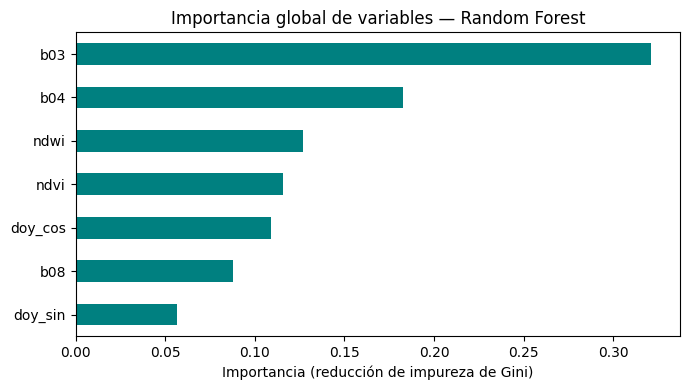

Importancia (de mayor a menor):


b03        0.321129
b04        0.182918
ndwi       0.127096
ndvi       0.115847
doy_cos    0.108843
b08        0.087703
doy_sin    0.056465
dtype: float64

In [34]:
# 8.1: importancia de variables del mejor modelo (Random Forest)
mejor_modelo = modelo_rf
importancias = pd.Series(mejor_modelo.feature_importances_, index=predictoras).sort_values()

plt.figure(figsize=(7, 4))
importancias.plot.barh(color="teal")
plt.title("Importancia global de variables — Random Forest")
plt.xlabel("Importancia (reducción de impureza de Gini)")
plt.tight_layout(); plt.savefig("importancia_variables.png", dpi=150); plt.show()

print("Importancia (de mayor a menor):")
importancias.sort_values(ascending=False)

### 8.2. Interpretación con SHAP

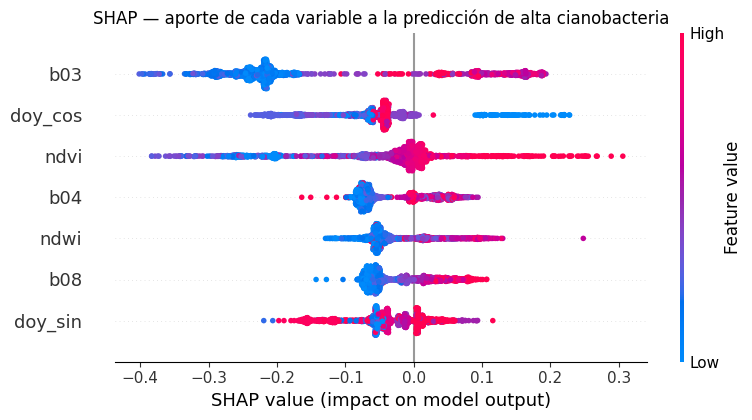

In [35]:
# 8.2: SHAP summary plot del mejor modelo (se muestrea para que sea rápido)
import shap

X_shap = X_test.sample(2000, random_state=42)
explainer = shap.TreeExplainer(mejor_modelo)
shap_values = explainer.shap_values(X_shap)

# Clasificador binario: usar los valores SHAP de la clase positiva (alta presencia)
if isinstance(shap_values, list):
    sv_pos = shap_values[1]
elif shap_values.ndim == 3:
    sv_pos = shap_values[:, :, 1]
else:
    sv_pos = shap_values

shap.summary_plot(sv_pos, X_shap, show=False)
plt.title("SHAP — aporte de cada variable a la predicción de alta cianobacteria")
plt.tight_layout(); plt.savefig("shap_summary.png", dpi=150); plt.show()